In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import math 

# Data Description 

> #### Dataset link: [**Credit Card Dataset for Clustering**](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)<br>
- `CUST_ID` : Identification of Credit Card holder (Categorical) <br>
- `BALANCE` : Balance amount left in their account to make purchases <br>
- `BALANCE_FREQUENCY` : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)<br>
- `PURCHASES` : Amount of purchases made from account<br>
- `ONEOFF_PURCHASES` : Maximum purchase amount done in one-go<br>
- `INSTALLMENTS_PURCHASES` : Amount of purchase done in installment<br>
- `CASH_ADVANCE` : Cash in advance given by the user<br>
- `PURCHASES_FREQUENCY` : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)<br>
- `ONEOFFPURCHASESFREQUENCY` : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)<br>
- `PURCHASESINSTALLMENTSFREQUENCY` : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)<br>
- `CASHADVANCEFREQUENCY` : How frequently the cash in advance being paid<br>
- `CASHADVANCETRX` : Number of Transactions made with "Cash in Advanced"<br>
- `PURCHASES_TRX` : Numbe of purchase transactions made<br>
- `CREDIT_LIMIT` : Limit of Credit Card for user<br>
- `PAYMENTS` : Amount of Payment done by user<br>
- `MINIMUM_PAYMENTS` : Minimum amount of payments made by user<br>
- `PRCFULLPAYMENT` : Percent of full payment paid by user<br>
- `TENURE` : Tenure of credit card service for user<br>


In [2]:
df = pd.read_csv("CC GENERAL.csv")
df.drop(columns=["CUST_ID"],inplace=True)
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [3]:
", ".join(df.columns.to_list())

'BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE'

# **Data Exploration**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [5]:
description = df.describe()
description

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
description.iloc[2,:]

BALANCE                             2081.531879
BALANCE_FREQUENCY                      0.236904
PURCHASES                           2136.634782
ONEOFF_PURCHASES                    1659.887917
INSTALLMENTS_PURCHASES               904.338115
CASH_ADVANCE                        2097.163877
PURCHASES_FREQUENCY                    0.401371
ONEOFF_PURCHASES_FREQUENCY             0.298336
PURCHASES_INSTALLMENTS_FREQUENCY       0.397448
CASH_ADVANCE_FREQUENCY                 0.200121
CASH_ADVANCE_TRX                       6.824647
PURCHASES_TRX                         24.857649
CREDIT_LIMIT                        3638.815725
PAYMENTS                            2895.063757
MINIMUM_PAYMENTS                    2372.446607
PRC_FULL_PAYMENT                       0.292499
TENURE                                 1.338331
Name: std, dtype: float64

### **There is a lot of `outliers` in this Data**

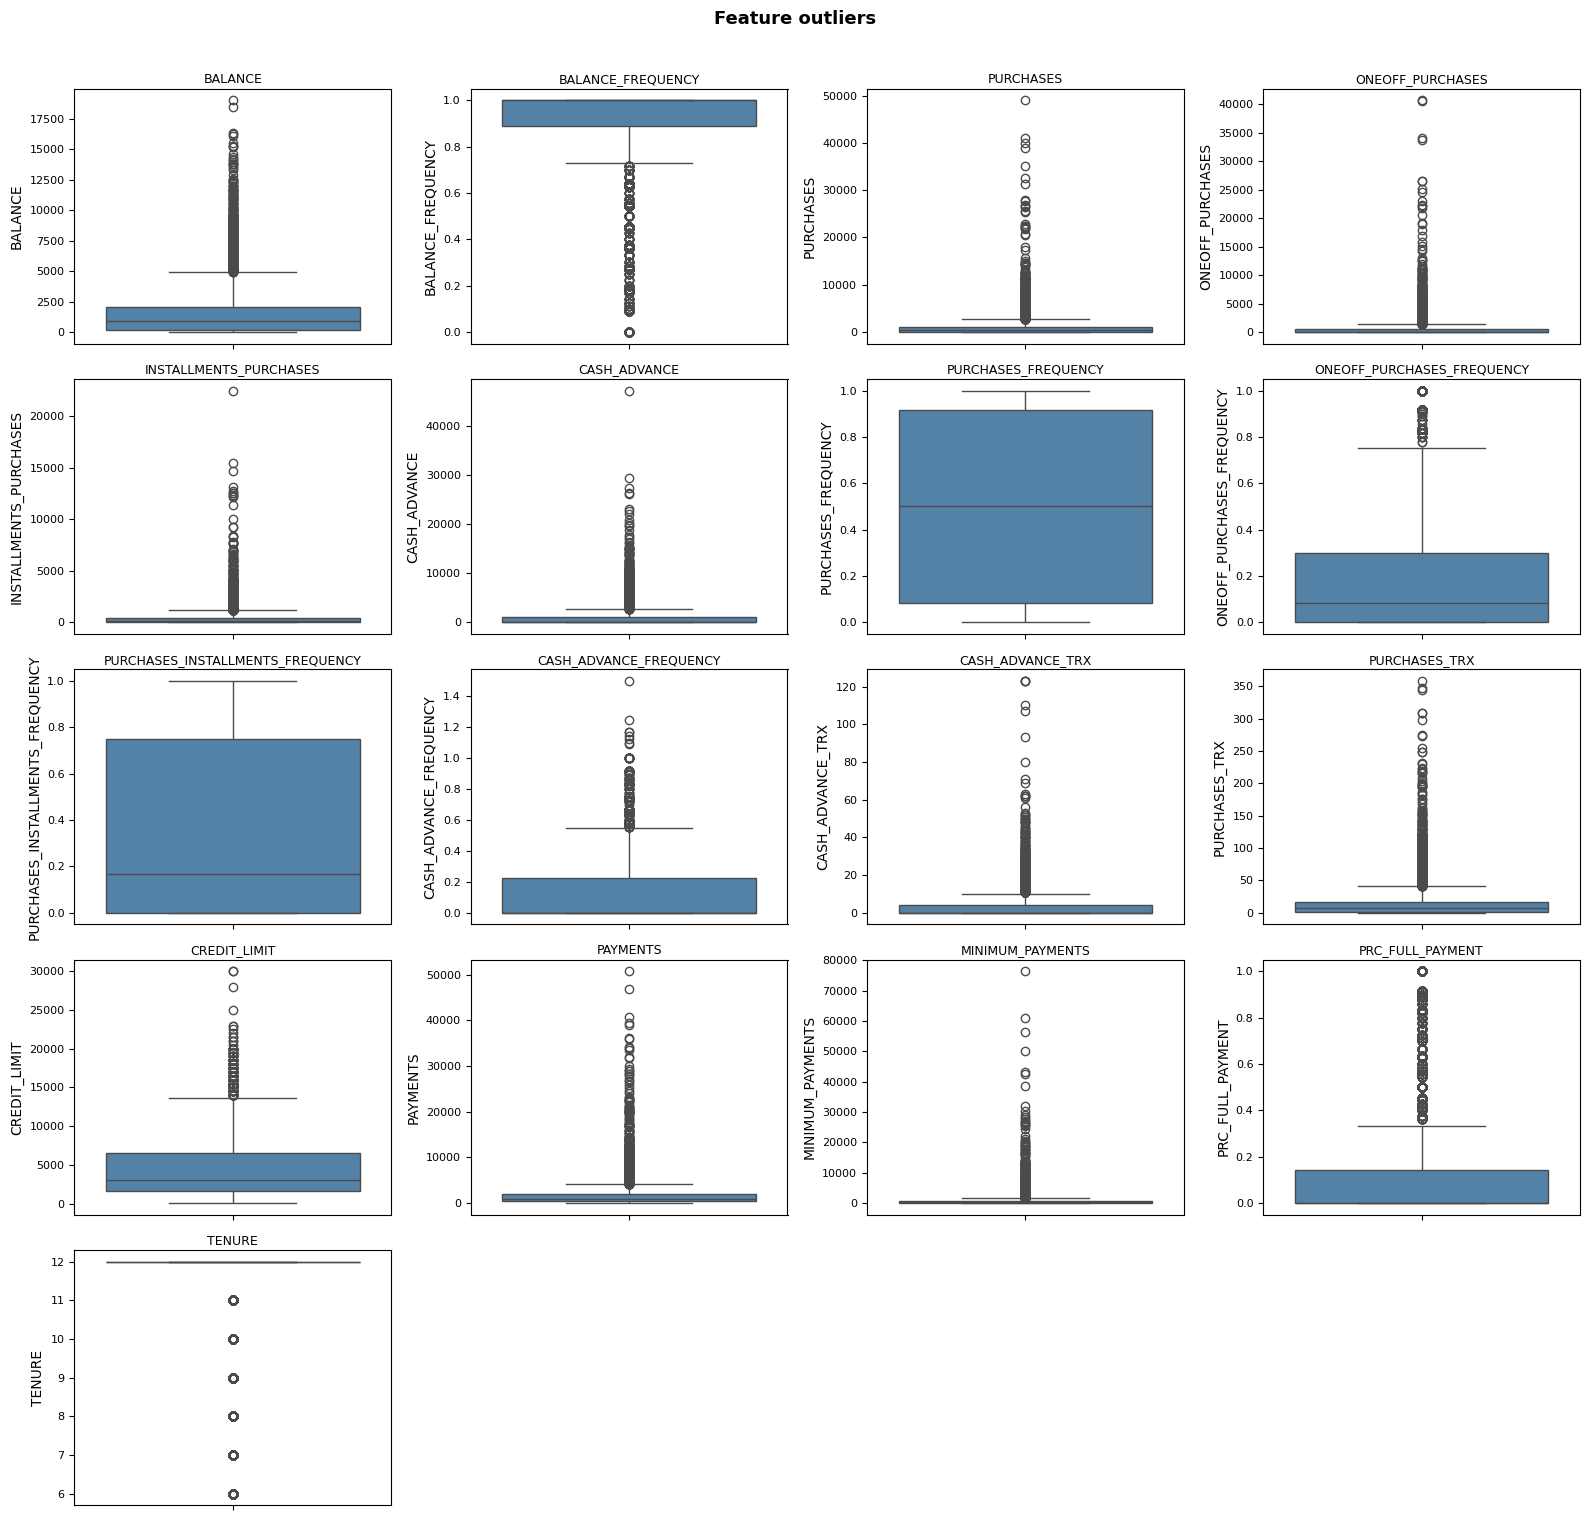

In [7]:
num_cols = df.select_dtypes(exclude="object").columns
n = len(num_cols)
ncols = 4
nrows = -(-n // ncols)  

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, column in enumerate(num_cols):
    sns.boxplot(data=df, y=column, ax=axes[i], color="steelblue")
    axes[i].set_title(column, fontsize=9, pad=4)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

#! Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature outliers", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## **Data Cleaning**

> * fillin Missing Values in **`MINIMUM_PAYMENTS`** & **`CREDIT_LIMIT`** with **`Median`** for it's Feature
> * we Use **`Median`** Because of outliers

In [8]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df.isnull().sum()



BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## **EDA**

> ###  Explore relations between Features

In [9]:
def Scatter(data: pd.DataFrame,x: str,y: str,size: str = None,style: str = None,title: str = None,figsize: tuple = (7,6)):
    sns.set_theme(style="whitegrid", context="notebook")
    plt.figure(figsize=figsize)
    sns.scatterplot(data=data,x=x,y=y,size=size,style=style,edgecolor="black",alpha=0.85)

    if not title:
        title = f"Relationship between {x} and {y}"

    plt.title(title, fontsize=14, weight="bold", pad=15)
    plt.xlabel(x, fontsize=11)
    plt.ylabel(y, fontsize=11)

    plt.grid(color="#2A2D3A", linestyle="--", linewidth=0.6, alpha=0.3)
    plt.tight_layout()
    plt.show()

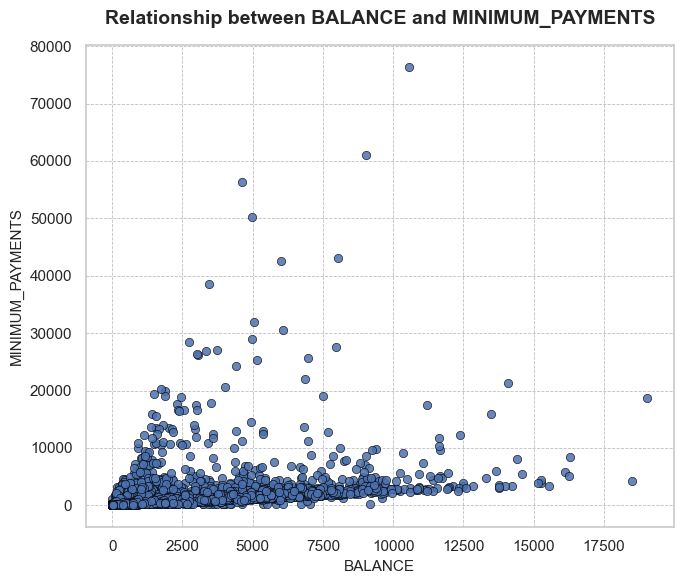

In [10]:
Scatter(data=df,x="BALANCE",y="MINIMUM_PAYMENTS")

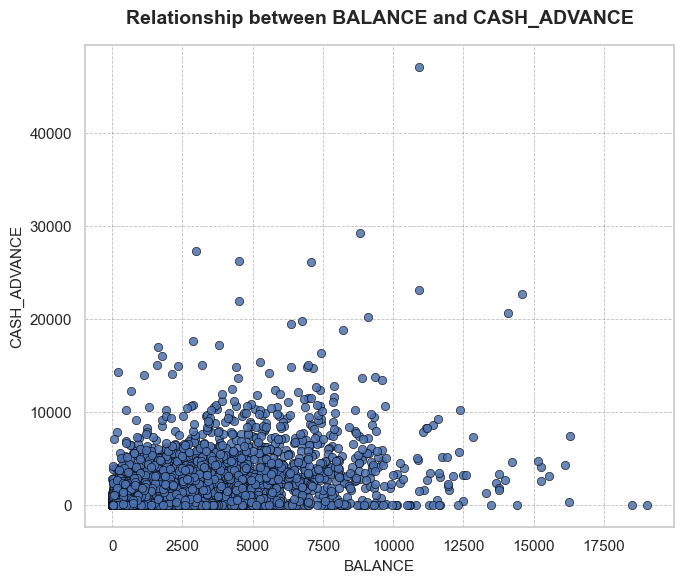

In [11]:
Scatter(data=df,x="BALANCE",y="CASH_ADVANCE")

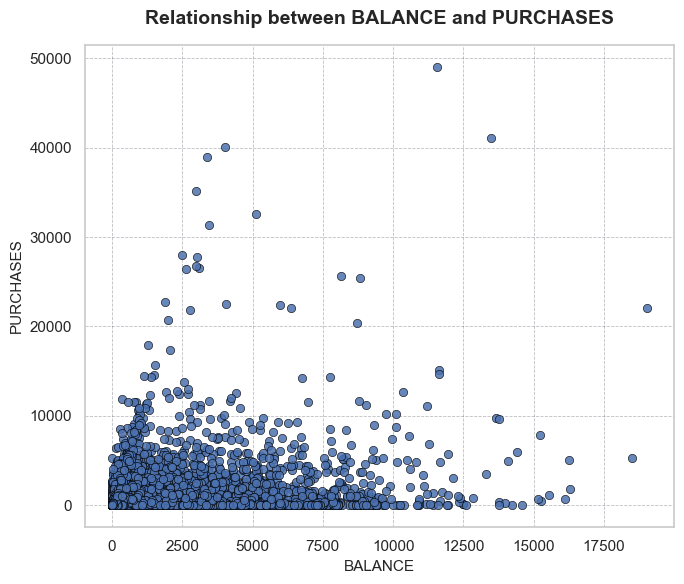

In [12]:
Scatter(data=df,x="BALANCE",y="PURCHASES")

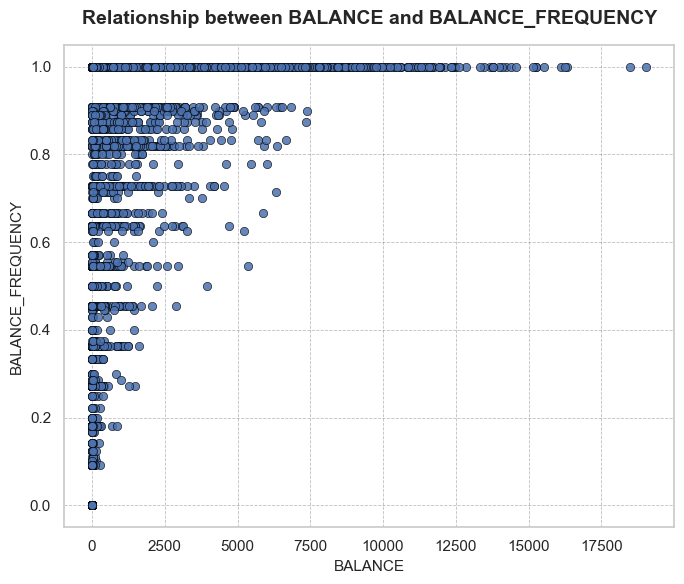

In [13]:
Scatter(data =df,x="BALANCE",y="BALANCE_FREQUENCY")

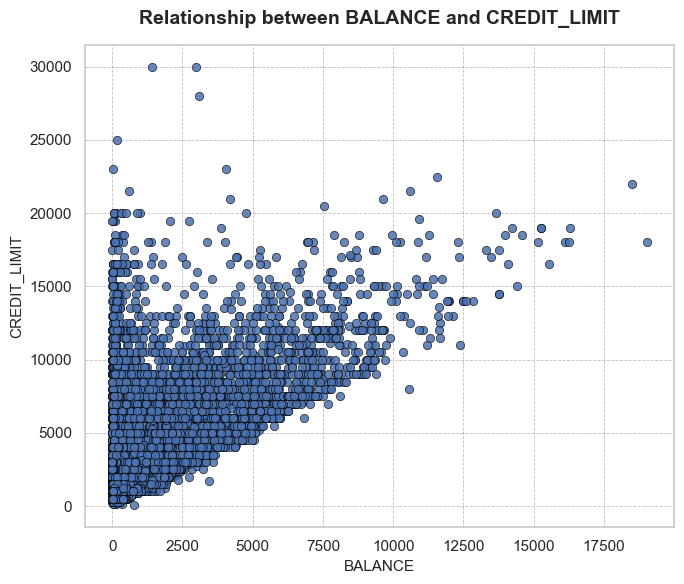

In [14]:
Scatter(data = df , x="BALANCE",y="CREDIT_LIMIT")

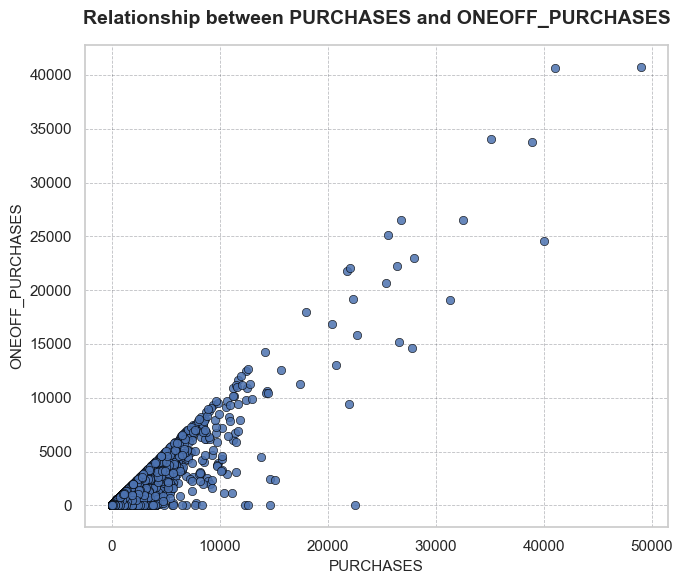

In [15]:
Scatter(data=df,x="PURCHASES",y="ONEOFF_PURCHASES")

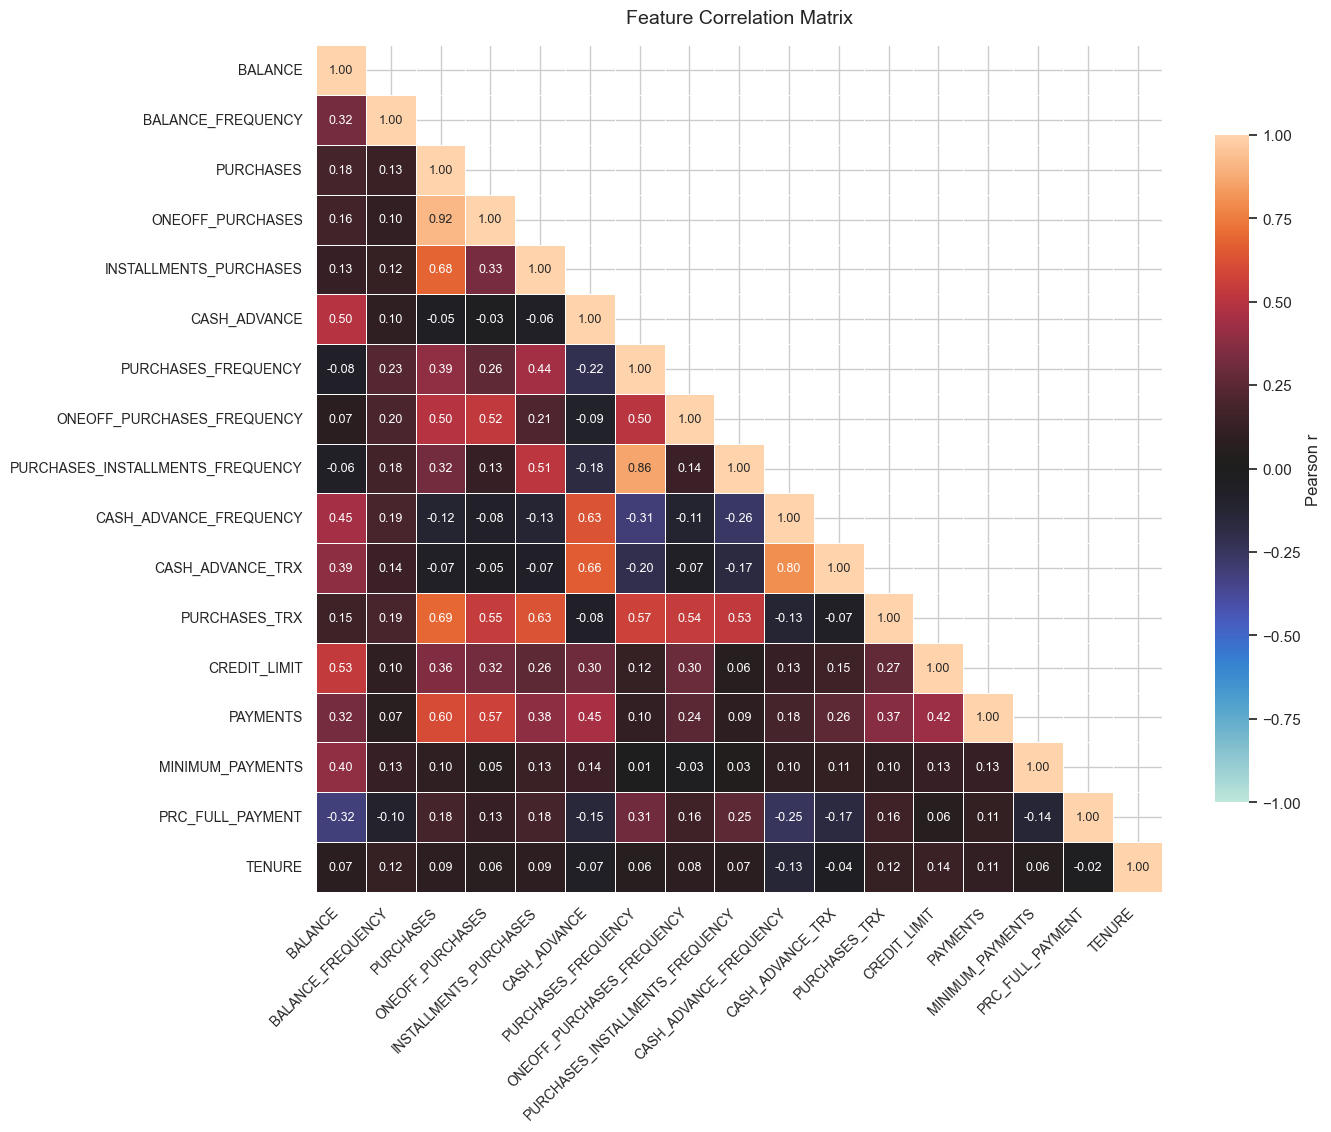

In [16]:
df_numeric = df.select_dtypes(exclude="object")
corr = df_numeric.corr()

n = len(corr)
mask = np.triu(np.ones_like(corr, dtype=bool),k=1)

fig, ax = plt.subplots(figsize=(14, 12))  

sns.heatmap(corr,mask=mask,annot=True,fmt=".2f",center=0,vmin=-1, vmax=1,square=True,linewidths=0.5,annot_kws={"size": 9},cbar_kws={"shrink": 0.7, "label": "Pearson r"},ax=ax)

ax.set_title("Feature Correlation Matrix", fontsize=14, pad=16)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

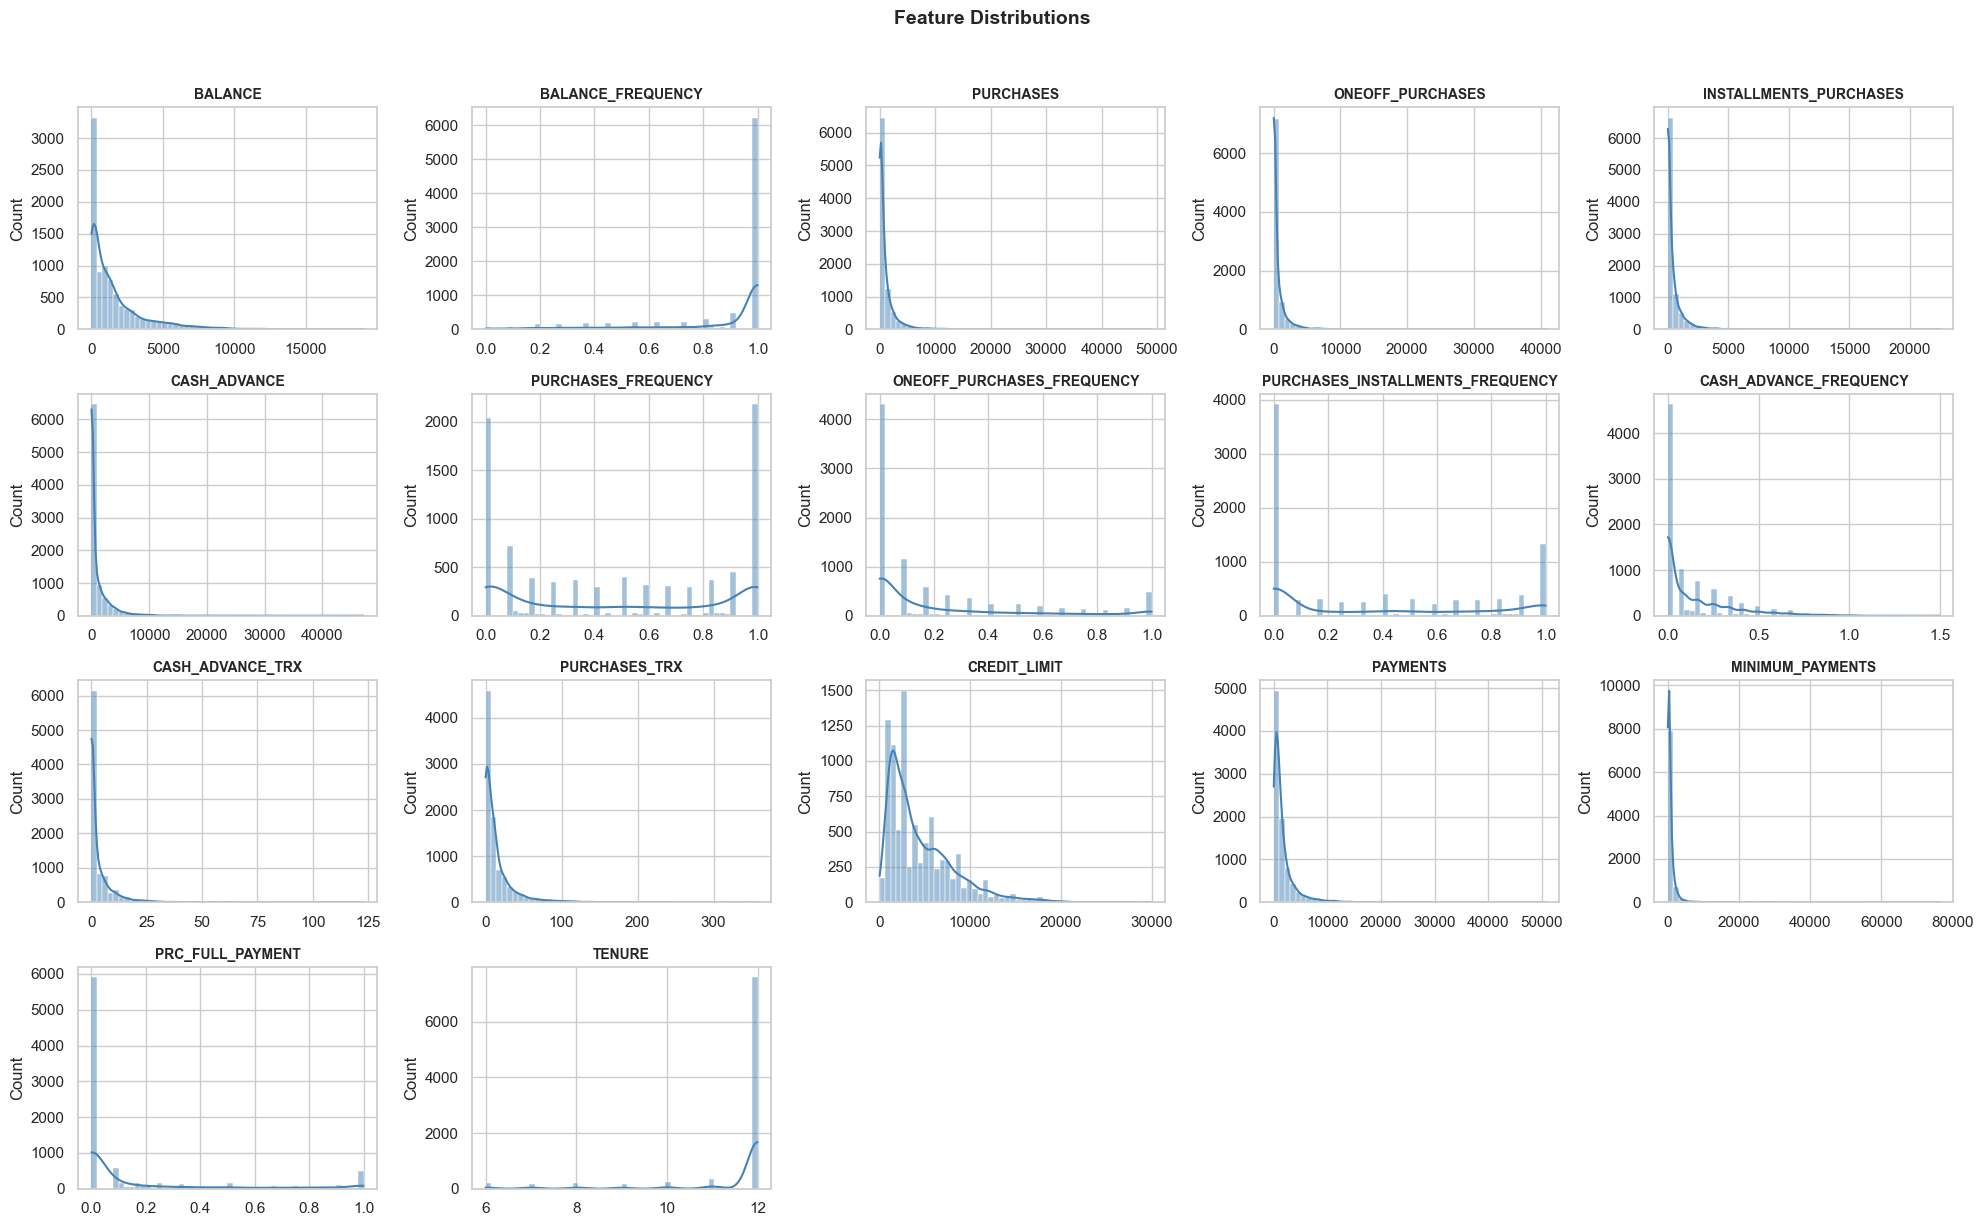

In [17]:
columns = df.select_dtypes(exclude="object").columns.tolist()

n_cols = 5
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, column in enumerate(columns):
    sns.histplot(data=df,x=column,bins=50,kde=True,color="steelblue",edgecolor="white",ax=axes[i])
    axes[i].set_title(column, fontsize=10, fontweight="bold")  
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [18]:
Skewnes = {}

for column in df.columns.to_list():
    Skewnes[column] = df[column].skew()

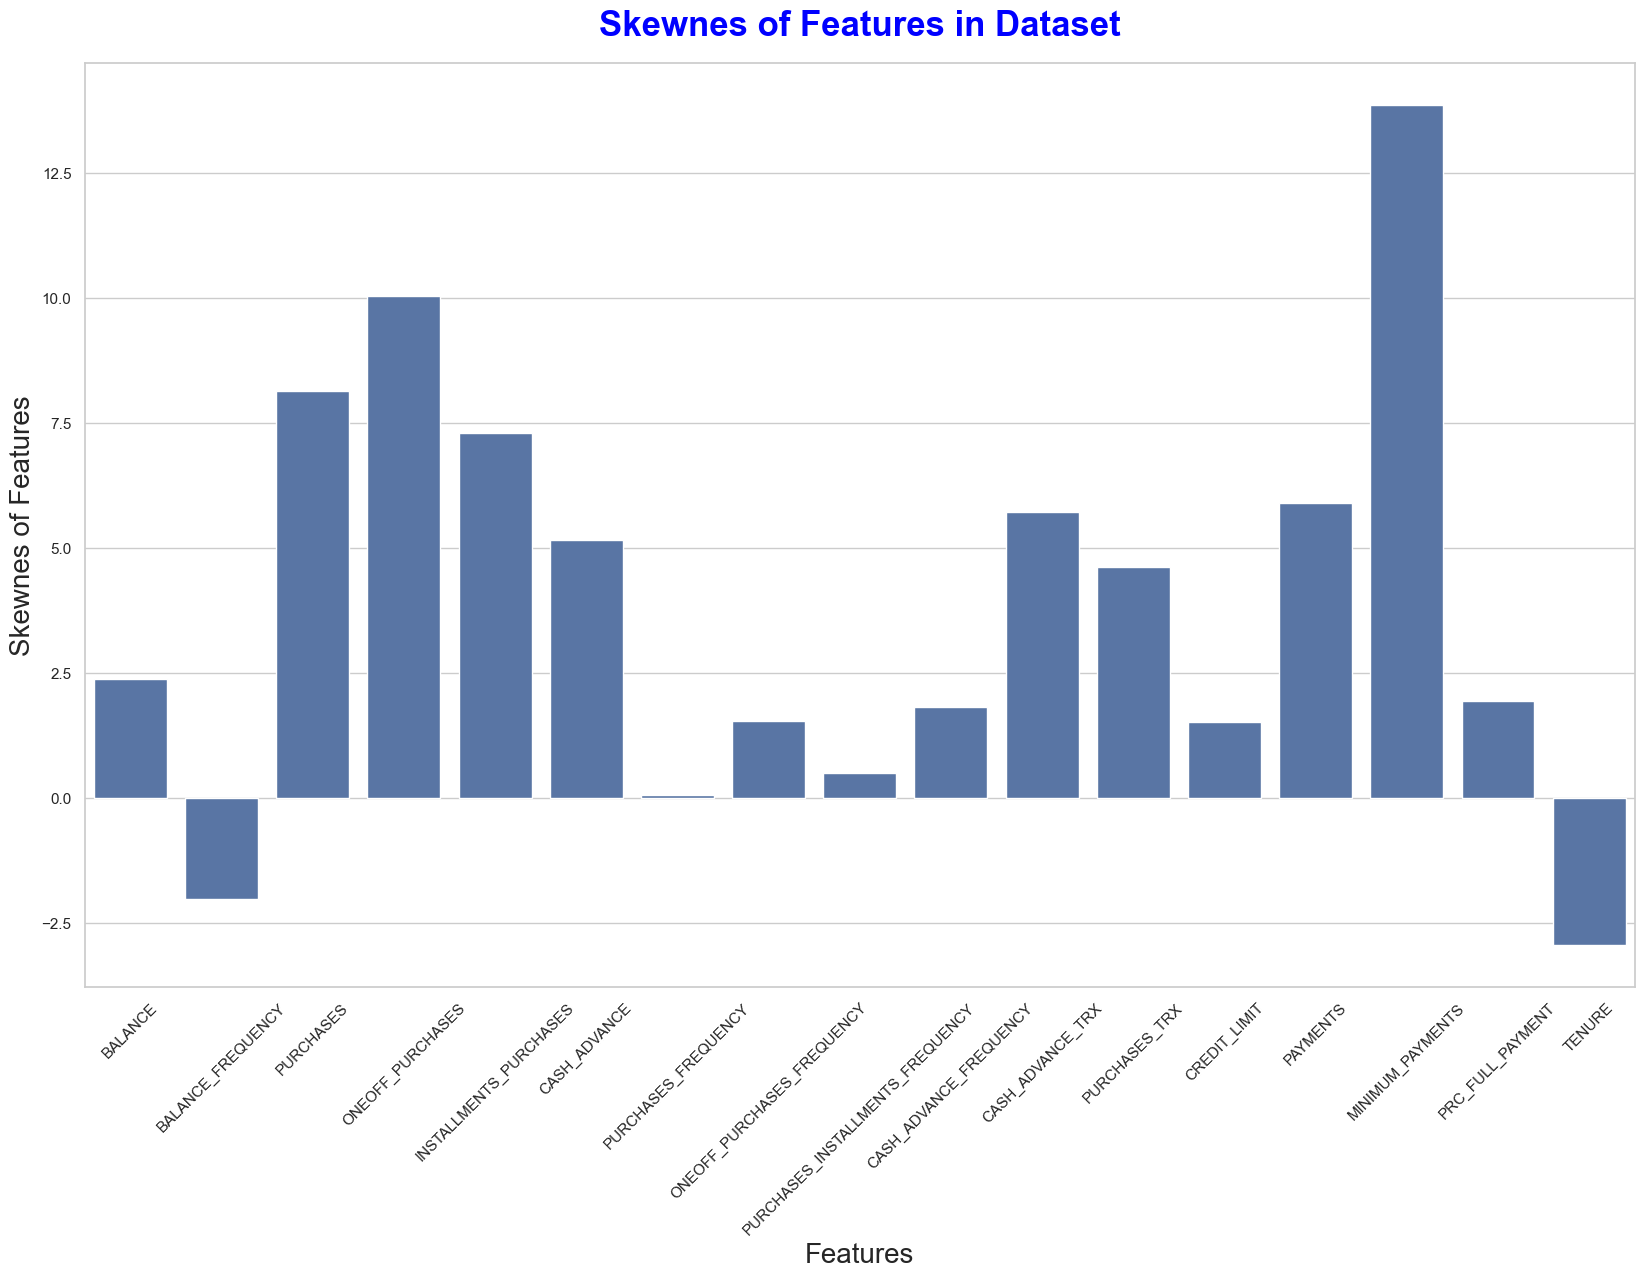

In [19]:
plt.figure(figsize=(20,12))
sns.barplot(x=Skewnes.keys(),y=Skewnes.values())
plt.title(label="Skewnes of Features in Dataset",size=25,weight="bold",pad=20,color="blue")
plt.ylabel(ylabel="Skewnes of Features",size=20)
plt.xlabel(xlabel="Features",size=20)
plt.xticks(rotation=45)
plt.show()

## 🛠 Data Preprocessing

In [20]:
df.drop(columns=["ONEOFF_PURCHASES","PURCHASES_INSTALLMENTS_FREQUENCY"],inplace=True)

In [21]:
right_skewed = [
    'BALANCE', 'PURCHASES', 
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
    'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'PAYMENTS', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT',
    'PRC_FULL_PAYMENT'
]

for col in right_skewed:
    df[col] = np.log1p(df[col])

print("Skewness after transformation:")
print(df[right_skewed].skew().round(2))

Skewness after transformation:
BALANCE                  -0.86
PURCHASES                -0.76
INSTALLMENTS_PURCHASES   -0.02
CASH_ADVANCE              0.26
CASH_ADVANCE_TRX          0.94
PURCHASES_TRX             0.03
PAYMENTS                 -1.78
MINIMUM_PAYMENTS          0.27
CREDIT_LIMIT             -0.10
PRC_FULL_PAYMENT          1.75
dtype: float64


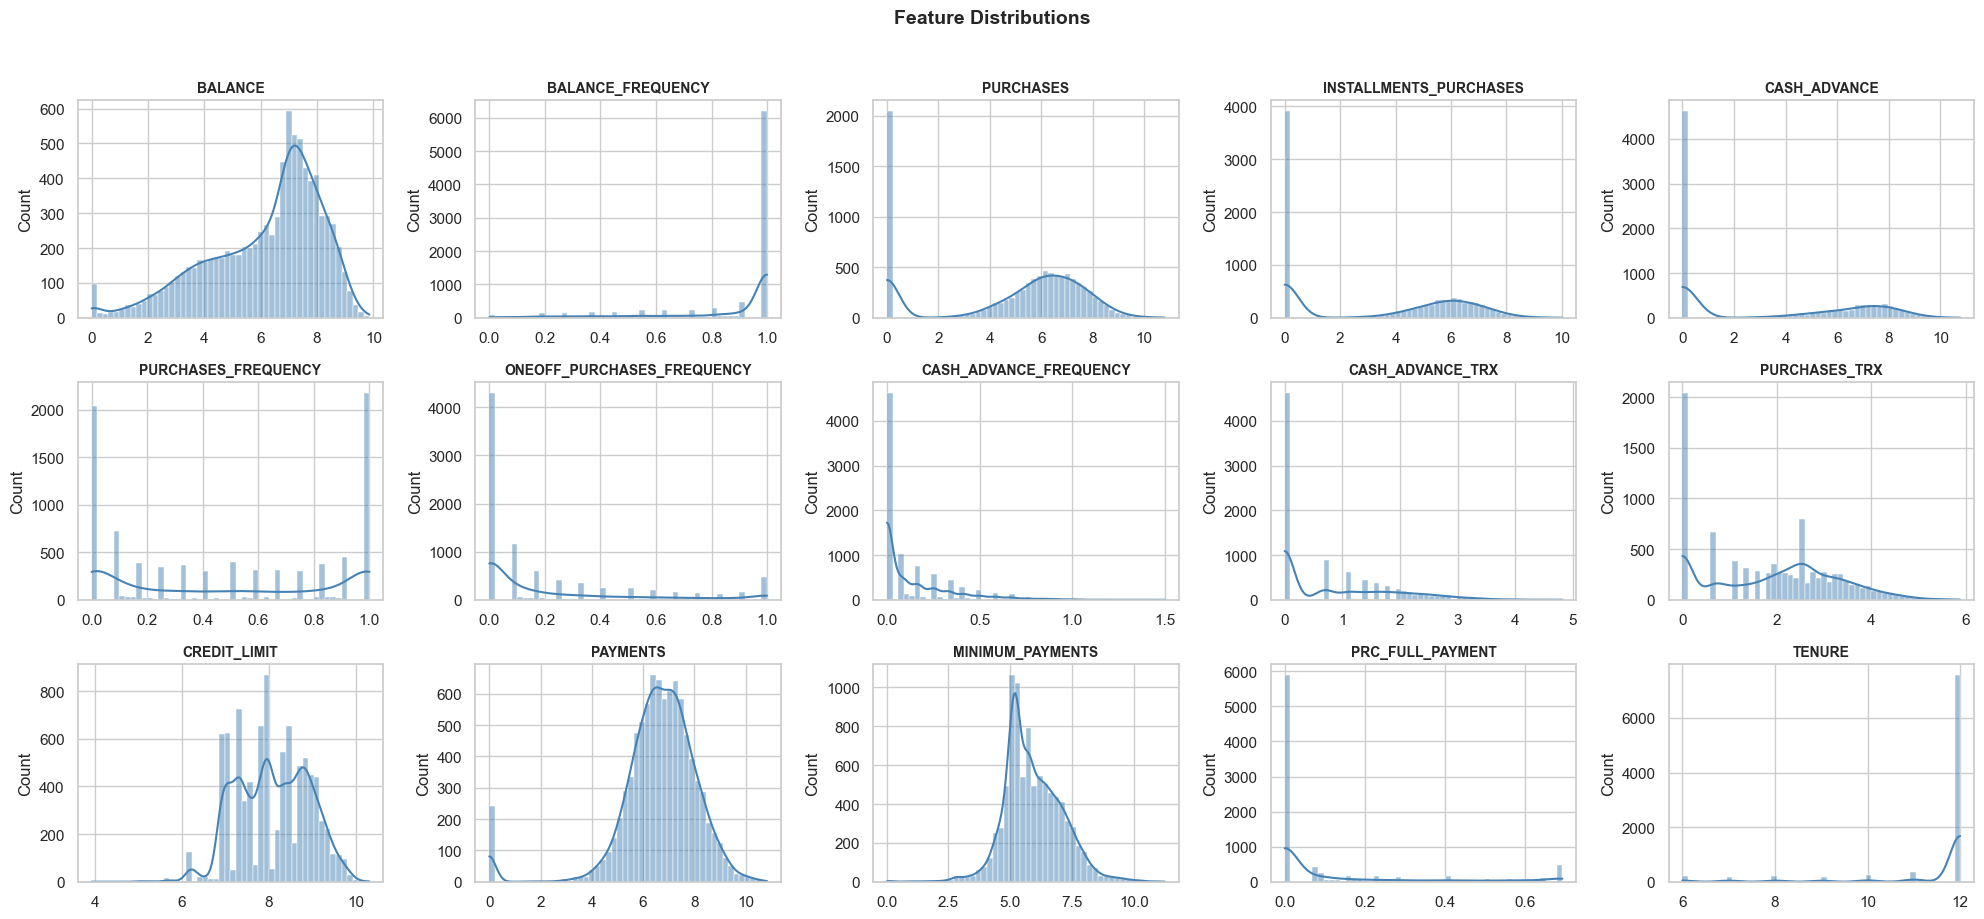

In [22]:
columns = df.select_dtypes(exclude="object").columns.tolist()

n_cols = 5
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, column in enumerate(columns):
    sns.histplot(data=df,x=column,bins=50,kde=True,color="steelblue",edgecolor="white",ax=axes[i])
    axes[i].set_title(column, fontsize=10, fontweight="bold")  
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## **NOW, WE WILL MAKE K-Means MODEL**

In [23]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

## **Scaling data before pass it to the model**

In [24]:
std_scaler = RobustScaler()
new_df = std_scaler.fit_transform(df)

## **Elbow Method to choose Best `k`**

In [43]:
k_values = range(3, 31)
sentroids = []
scores = []
for k in k_values:
    algo = KMeans(n_clusters=k,random_state=42,n_init=20,init="k-means++")
    algo.fit(new_df)
    sentroids.append(algo.inertia_)
    scores.append(silhouette_score(new_df,algo.labels_,random_state=42))

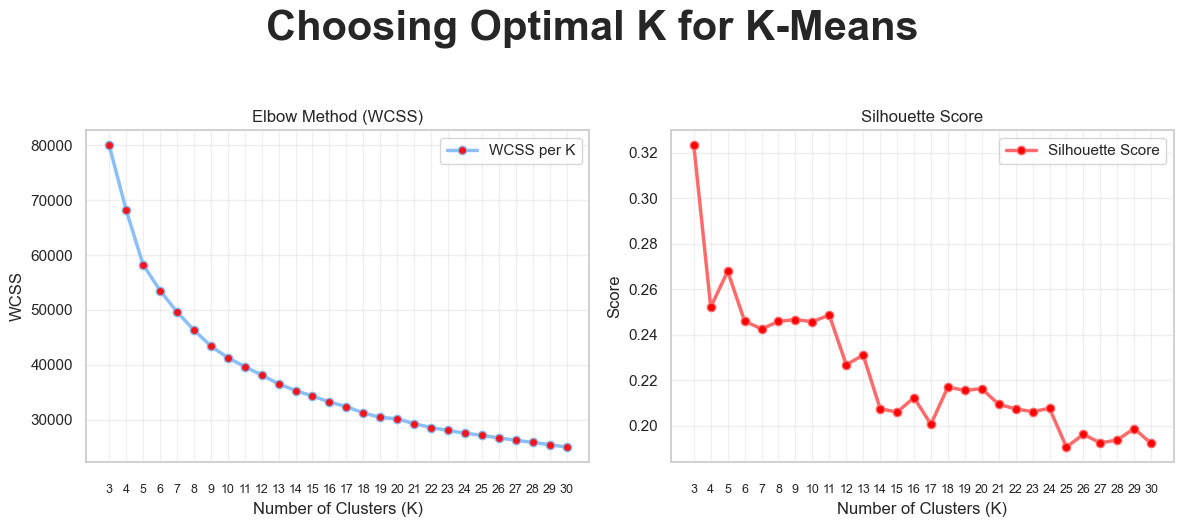

In [44]:
plt.figure(figsize=(12,5))

# --- Subplot 1 : Elbow (WCSS) ---
plt.subplot(1,2,1)
plt.plot(k_values,sentroids, marker="o",markerfacecolor="red",color="#7EB8F7",linewidth=2.5,alpha=0.9,label="WCSS per K")
plt.title("Elbow Method (WCSS)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tick_params(axis='x',labelsize=9, pad=10)
plt.legend()

# --- Subplot 2 : Silhouette ---
plt.subplot(1,2,2)
plt.plot(k_values,scores, marker="o",markerfacecolor="red",color="#FF6B6B",linewidth=2.5,label="Silhouette Score")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(k_values)
plt.tick_params(axis='x',labelsize=9, pad=10)


plt.suptitle("Choosing Optimal K for K-Means", size = 30,y=1.05,weight="bold")
plt.tight_layout()
plt.show()

## **Passing Data to Kmeans algorithm**

In [27]:
n_clusters=3
model = KMeans(n_clusters=n_clusters,random_state=42,n_init=20,init="k-means++")
model.fit(new_df)
labels = model.labels_
sentroids = model.cluster_centers_

In [28]:
clusters=pd.concat([df, pd.DataFrame({'cluster':labels})], axis=1)
clusters.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,3.735304,0.818182,4.568506,4.568506,0.000000,0.166667,0.000000,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12,2
1,8.071989,0.909091,0.000000,0.000000,8.770896,0.000000,0.000000,0.250000,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,12,2
2,7.822504,1.000000,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12,2
3,7.419183,0.636364,7.313220,0.000000,5.331694,0.083333,0.083333,0.083333,0.693147,0.693147,8.922792,0.000000,5.747301,0.000000,12,0
4,6.707735,1.000000,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12,2


## **Reduce Dimensionality Data  to visualise it**

In [29]:
pca_model = PCA(n_components=2,random_state=42)
PCA_data = pca_model.fit_transform(new_df)
new_sentroids = pca_model.transform(sentroids)

In [30]:
dist = cosine_similarity(new_df)
pca_model = PCA(n_components=2,random_state=42)
PCA_data2 = pca_model.fit_transform(dist)


In [31]:
score = silhouette_score(new_df,labels,random_state=42)
print(f"K-Means Silhouette Score = {score:0.2f}")

K-Means Silhouette Score = 0.32


## **Final Result**

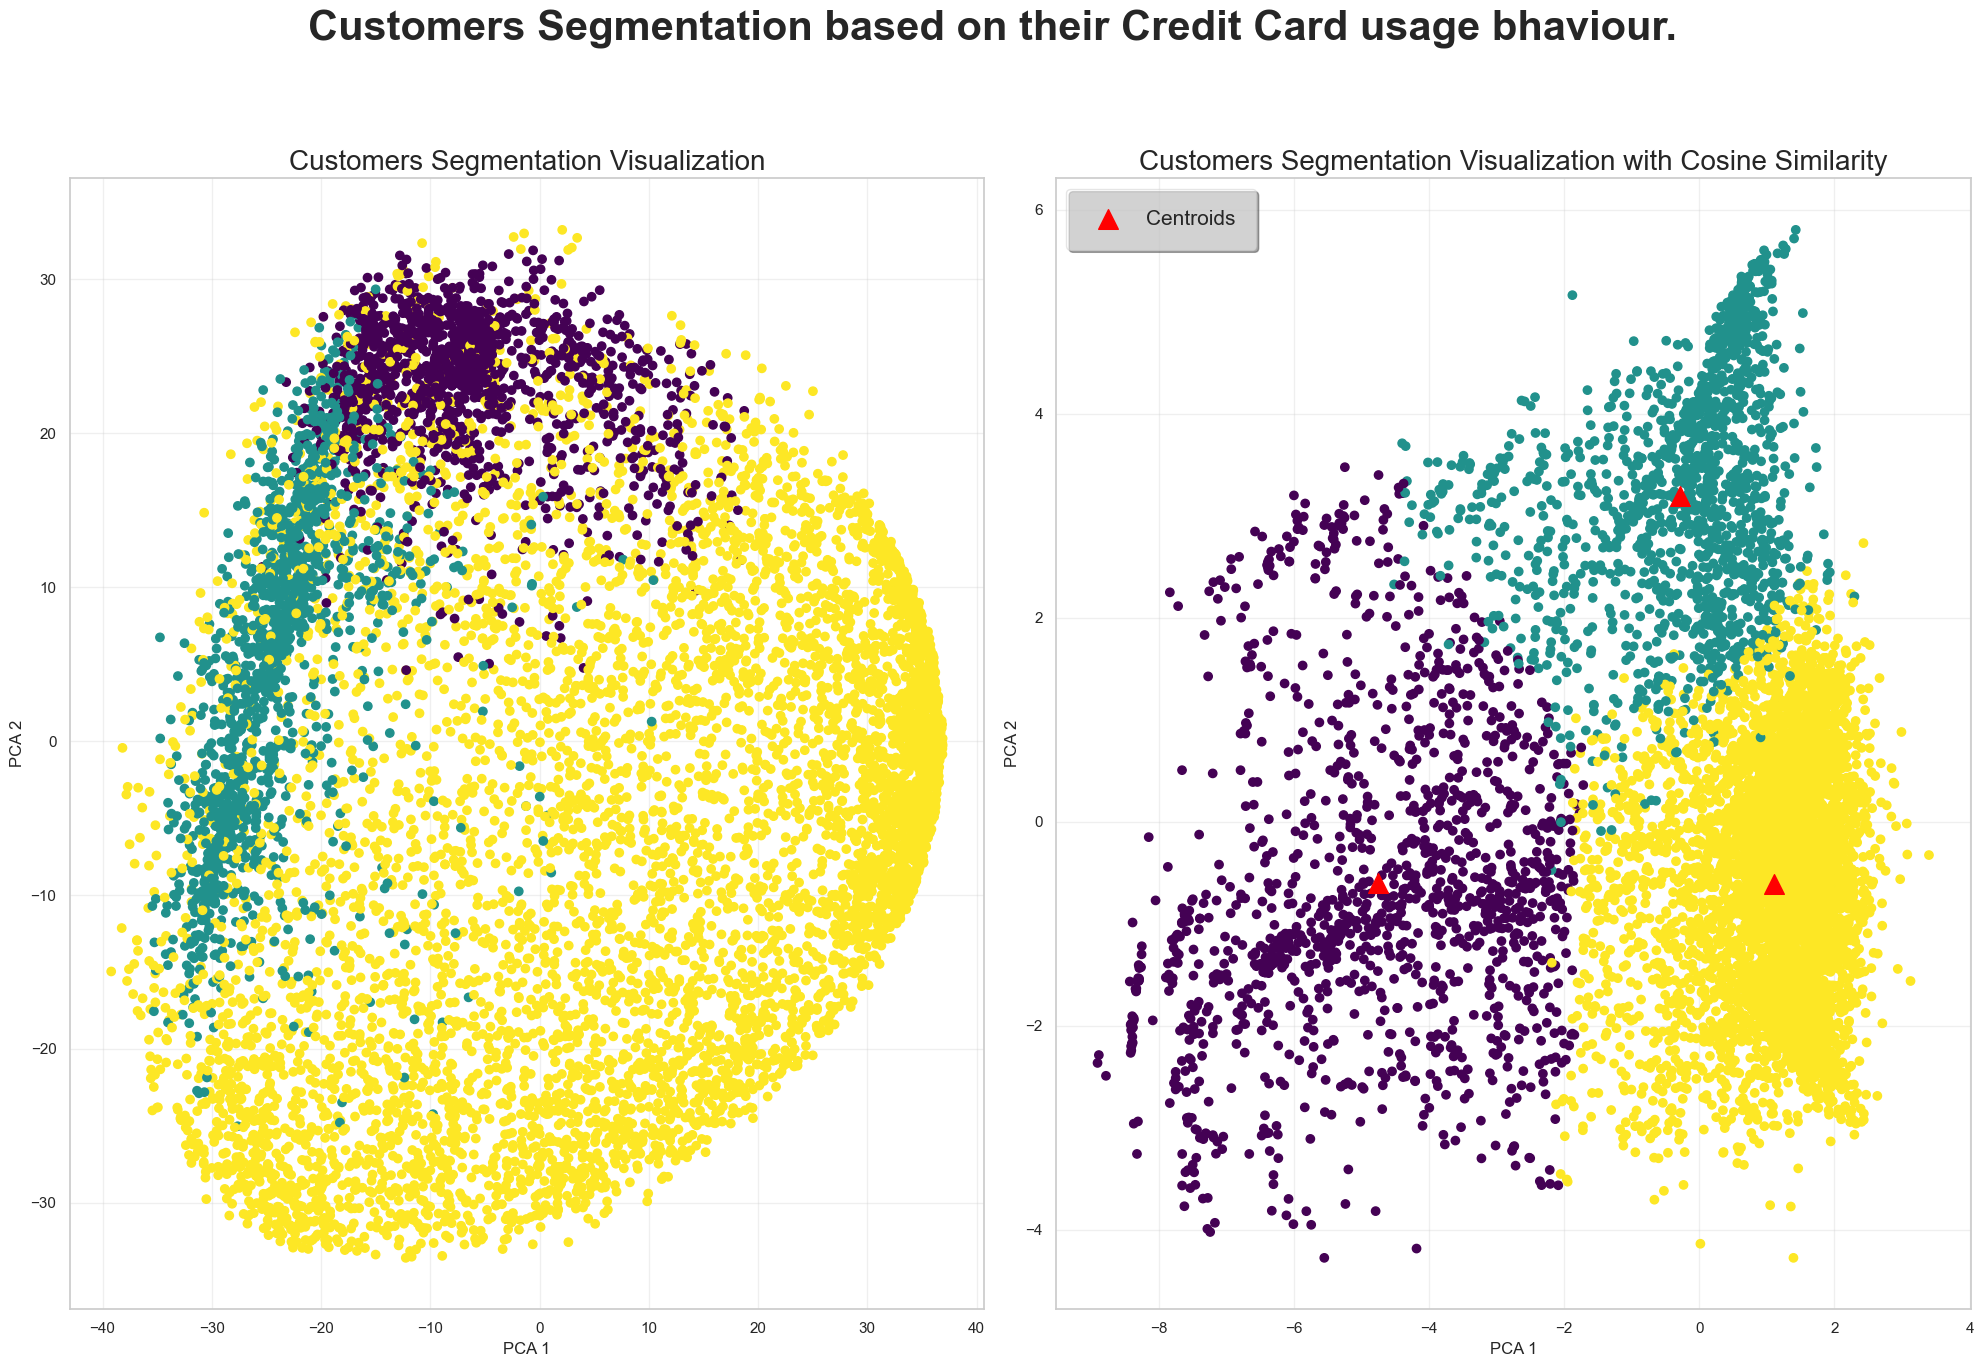

In [46]:
plt.figure(figsize=(20,13))

# --- Subplot 1 ---
plt.subplot(1,2,1)
plt.scatter(PCA_data2[:,0], PCA_data2[:,1], marker='o',c=labels,cmap="viridis")
plt.title("Customers Segmentation Visualization",size=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)

# --- Subplot 2 ---
plt.subplot(1,2,2)
plt.scatter(PCA_data[:,0], PCA_data[:,1], marker='o',c=labels,cmap="viridis")
plt.scatter(new_sentroids[:,0], new_sentroids[:,1], marker='^',color = "red",s=200,label="Centroids")
plt.title("Customers Segmentation Visualization with Cosine Similarity",size=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)
plt.legend(frameon=True,ncol=1,fancybox=True,framealpha=0.5,shadow=True,borderpad=1,fontsize=15)


plt.suptitle("Customers Segmentation based on their Credit Card usage bhaviour.",size = 30,y=1.05,weight="bold")
plt.tight_layout()
plt.show()

## **FINALLY, WE WILL MAKE CLASSIFICATION MODEL**

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report


## **Add Target Label to our Data**

In [34]:
data = pd.DataFrame(new_df,columns=df.columns)
data["TARGET"] = labels
data

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TARGET
0,-1.098374,-1.636364,-0.400154,0.011167,0.000000,-0.399999,-0.277777,0.000000,0.000000,-0.446395,-0.783504,-0.901767,-0.525916,0.000000,0.0,2
1,0.469421,-0.818182,-1.780990,-0.731443,1.250048,-0.600000,-0.277777,1.125001,1.000000,-0.946395,0.604504,0.978658,0.807362,1.502798,0.0,2
2,0.379228,0.000000,0.229522,-0.731443,0.000000,0.600000,3.055557,0.000000,0.000000,0.220964,0.653731,-0.199976,0.456190,0.000000,0.0,2
3,0.233419,-3.272727,0.429440,-0.731443,0.759885,-0.500000,0.000000,0.374999,0.430677,-0.630930,0.653731,-4.223218,0.000000,0.000000,0.0,0
4,-0.023783,0.000000,-0.924648,-0.731443,0.000000,-0.500000,0.000000,0.000000,0.000000,-0.630930,-0.653517,-0.145917,-0.159225,0.000000,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-1.225316,0.000000,-0.065060,0.191379,0.000000,0.600000,-0.277777,0.000000,0.000000,-0.060773,-0.783504,-0.603844,-1.204950,3.036481,-6.0,1
8946,-1.362447,0.000000,-0.056009,0.196246,0.000000,0.600000,-0.277777,0.000000,0.000000,-0.060773,-0.783504,-0.707136,0.000000,0.000000,-6.0,2
8947,-1.293875,-1.500005,-0.275934,0.077972,0.000000,0.399999,-0.277777,0.000000,0.000000,-0.130930,-0.783504,-1.465873,-0.867823,1.671096,-6.0,1
8948,-1.483062,-1.500005,-1.780990,-0.731443,0.516772,-0.600000,-0.277777,0.750002,0.682606,-0.946395,-1.277428,-1.734354,-1.120356,1.671096,-6.0,2


## **Split Data to train & test**

In [35]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]
x_train ,x_test , y_train,y_test = train_test_split(x,y,random_state=42,train_size=0.8)

### **Choosing the best number for `n_estimators` for RandomForest**

In [36]:
tress = []
accuracy = []

for tree in range(5,156,10):
    classifier = RandomForestClassifier(n_estimators=tree,random_state=42)
    classifier.fit(x_train,y_train)
    y_predict = classifier.predict(x_test)
    tress.append(tree)
    accuracy.append(accuracy_score(y_test,y_predict))




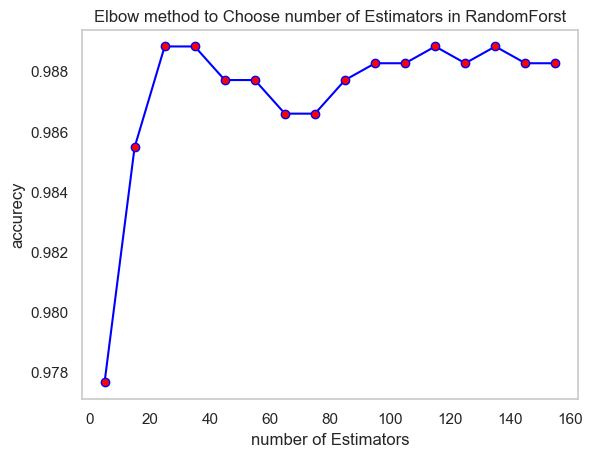

In [37]:
plt.plot(tress,accuracy,marker="o",c="blue",markerfacecolor="red")
plt.title("Elbow method to Choose number of Estimators in RandomForst")
plt.xlabel("number of Estimators")
plt.ylabel("accurecy")
plt.grid()
plt.show()

## **`25` is the best number of estimators**

In [38]:
classifier = RandomForestClassifier(n_estimators=25,random_state=42)
classifier.fit(x_train,y_train)
y_predict = classifier.predict(x_test)

> ## **Model Evaluation**

In [39]:
acc = accuracy_score(y_test,y_predict)
print(f"Model Accuracy = {acc *100:0.2f}%")

Model Accuracy = 98.88%


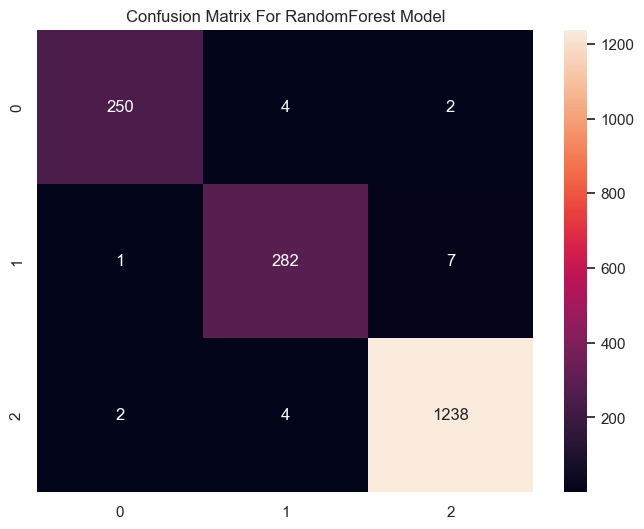

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_predict),annot=True,fmt=".0f")
plt.title("Confusion Matrix For RandomForest Model")
plt.show()

In [41]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       256
           1       0.97      0.97      0.97       290
           2       0.99      1.00      0.99      1244

    accuracy                           0.99      1790
   macro avg       0.98      0.98      0.98      1790
weighted avg       0.99      0.99      0.99      1790



---

<h1 align="center">The End of model 😎</h1>


---
